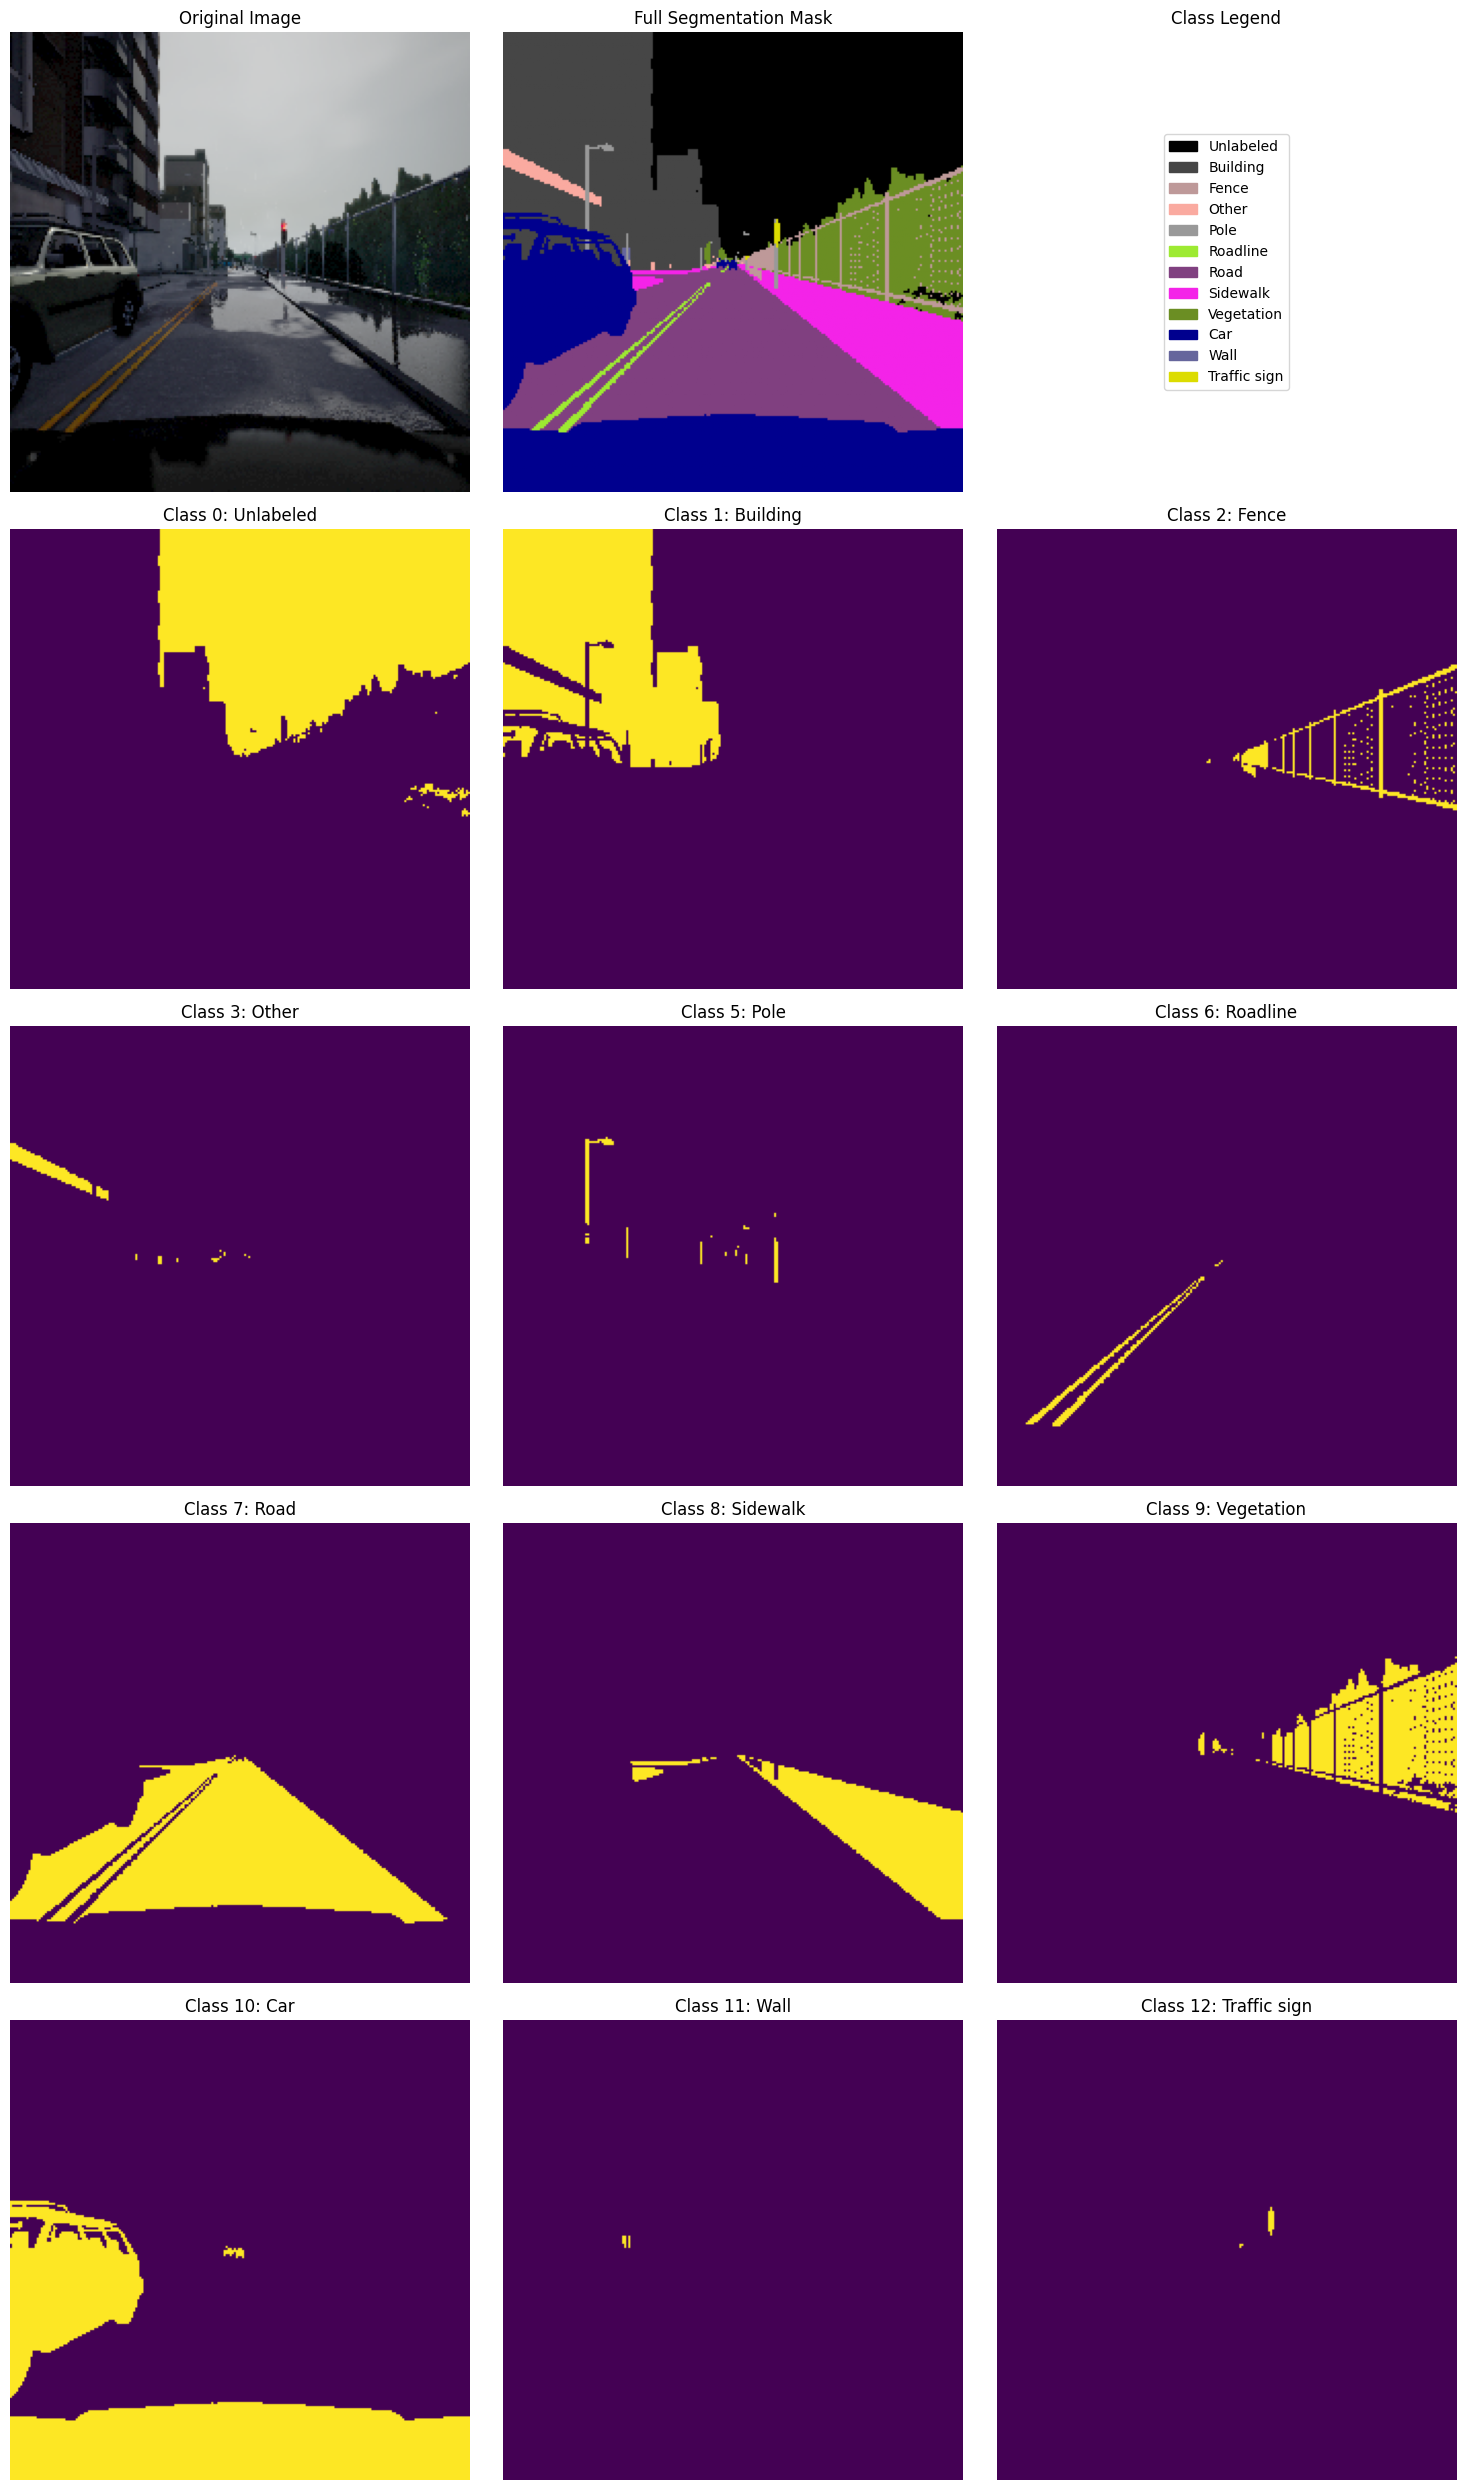

In [ ]:
# -*- coding: utf-8 -*-fine tuning 2nd PART

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as transforms
from matplotlib.colors import ListedColormap

def visualize_segmentation_classes(image_path, mask_path, output_dir=None):
    """
    Visualize the input image, full segmentation mask, and individual class masks
    
    Args:
        image_path: Path to the input image
        mask_path: Path to the corresponding segmentation mask
        output_dir: Directory to save visualizations (if None, only displays)
    """
    # Class names for the dataset
    class_names = [
        "Unlabeled", "Building", "Fence", "Other", "Pedestrian", 
        "Pole", "Roadline", "Road", "Sidewalk", "Vegetation", 
        "Car", "Wall", "Traffic sign"
    ]
    
    # Define a colormap for visualization
    colors = [
        [0, 0, 0],        # Unlabeled - black
        [70, 70, 70],     # Building - dark gray
        [190, 153, 153],  # Fence - light brown
        [250, 170, 160],  # Other - salmon
        [220, 20, 60],    # Pedestrian - crimson
        [153, 153, 153],  # Pole - gray
        [157, 234, 50],   # Roadline - bright green
        [128, 64, 128],   # Road - purple
        [244, 35, 232],   # Sidewalk - pink
        [107, 142, 35],   # Vegetation - olive green
        [0, 0, 142],      # Car - dark blue
        [102, 102, 156],  # Wall - slate blue
        [220, 220, 0]     # Traffic sign - yellow
    ]
    # Normalize colors to [0, 1] for matplotlib
    colors = np.array(colors) / 255.0
    cmap = ListedColormap(colors)
    
    # Load image and mask
    image = Image.open(image_path).convert('RGB')
    mask = Image.open(mask_path)
    
    # Convert mask to numpy array and get first channel (class IDs)
    mask_array = np.array(mask)
    if len(mask_array.shape) == 3:
        class_mask = mask_array[:, :, 0]  # Extract first channel
    else:
        class_mask = mask_array
    
    # Get unique classes in this mask
    unique_classes = np.unique(class_mask)
    
    # Set up the figure layout
    num_classes = len(unique_classes)
    fig_rows = int(np.ceil((num_classes + 2) / 3))  # +2 for image and full mask
    
    fig, axes = plt.subplots(fig_rows, 3, figsize=(15, 5 * fig_rows))
    if fig_rows == 1:
        axes = axes.reshape(1, -1)
    
    # Plot original image
    axes[0, 0].imshow(image)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # Plot full segmentation mask with color mapping
    colored_mask = cmap(class_mask)
    axes[0, 1].imshow(colored_mask)
    axes[0, 1].set_title('Full Segmentation Mask')
    axes[0, 1].axis('off')
    
    # Create a legend for the classes
    legend_elements = [plt.Rectangle((0, 0), 1, 1, color=colors[i], label=class_names[i]) 
                      for i in range(len(class_names)) if i in unique_classes]
    axes[0, 2].legend(handles=legend_elements, loc='center')
    axes[0, 2].axis('off')
    axes[0, 2].set_title('Class Legend')
    
    # Plot individual class masks
    idx = 0
    for row in range(1, fig_rows):
        for col in range(3):
            if idx < num_classes:
                class_id = unique_classes[idx]
                idx += 1
                
                # Create binary mask for this class
                binary_mask = (class_mask == class_id).astype(np.uint8)
                
                # Plot the binary mask
                axes[row, col].imshow(binary_mask)
                axes[row, col].set_title(f'Class {class_id}: {class_names[class_id]}')
                axes[row, col].axis('off')
            else:
                axes[row, col].axis('off')
    
    plt.tight_layout()
    
    # Save figure if output directory is provided
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        base_name = os.path.basename(image_path).split('.')[0]
        plt.savefig(os.path.join(output_dir, f"{base_name}_visualization.png"))
    
    plt.show()



# Example usage
if __name__ == "__main__":
    # Path to your dataset
    dataset_path = "Dataset/1/dataset_224/train"

    # Alternatively, visualize a specific image and its mask
    image_path = "Dataset/1/dataset_224/train/images/02_00_000.png"
    mask_path = "Dataset/1/dataset_224/train/labels/02_00_000.png"
    visualize_segmentation_classes(image_path, mask_path)

In [2]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import numpy as np

class SegmentationDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        """
        Args:
            root_dir (string): Path to the dataset directory (Dataset/1/dataset_224/)
            split (string): 'train' or 'test'
            transform (callable, optional): Optional transform to be applied on images
        """
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        
        # Define paths
        self.image_dir = os.path.join(root_dir, split, 'images')
        self.mask_dir = os.path.join(root_dir, split, 'labels')
        
        # Get list of files
        self.images = sorted(os.listdir(self.image_dir))
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Load image and mask
        img_name = self.images[idx]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        mask = Image.open(mask_path)
        
        # Convert to numpy arrays
        image = np.array(image)
        mask = np.array(mask)
        
        # Extract first channel of mask (class IDs)
        if len(mask.shape) == 3:
            mask = mask[:, :, 0]
        
        # Convert to torch tensors
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        mask = torch.from_numpy(mask).long()
        
        # Apply transforms if any
        if self.transform is not None:
            image = self.transform(image)
        
        return image, mask

def get_data_loaders(data_dir, batch_size=25, num_workers=4):
    """Create train and test data loaders"""
    
    # Define transforms
    transform = transforms.Compose([
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
    ])
    
    # Create datasets
    train_dataset = SegmentationDataset(
        root_dir=data_dir,
        split='train',
        transform=transform
    )
    
    test_dataset = SegmentationDataset(
        root_dir=data_dir,
        split='test',
        transform=transform
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    return train_loader, test_loader

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchmetrics.segmentation import MeanIoU
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torchmetrics.segmentation import MeanIoU
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

def train_model(model, train_loader, test_loader, num_epochs=50, device='cuda', learning_rate=1e-4):
    """Train the FCN model"""
    
    # Move model to device
    model = model.to(device)
    
    # Define loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)  # Now using the learning_rate parameter
    
    # Initialize metrics
    metric = MeanIoU(num_classes=13).to(device)
    
    # Training history
    history = {
        'train_loss': [],
        'train_miou': [],
        'val_loss': [],
        'val_miou': []
    }
    
    # Training loop
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_miou = 0
        
        for images, masks in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            # Backward pass and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            # Update metrics
            train_loss += loss.item()
            train_miou += metric(outputs.argmax(1), masks).item()
        
        # Calculate average metrics
        train_loss /= len(train_loader)
        train_miou /= len(train_loader)
        
        # Validation phase
        model.eval()
        val_loss = 0
        val_miou = 0
        
        with torch.no_grad():
            for images, masks in test_loader:
                images = images.to(device)
                masks = masks.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, masks)
                
                val_loss += loss.item()
                val_miou += metric(outputs.argmax(1), masks).item()
        
        val_loss /= len(test_loader)
        val_miou /= len(test_loader)
        
        # Update history
        history['train_loss'].append(train_loss)
        history['train_miou'].append(train_miou)
        history['val_loss'].append(val_loss)
        history['val_miou'].append(val_miou)
        
        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {train_loss:.4f}, Train mIoU: {train_miou:.4f}')
        print(f'Val Loss: {val_loss:.4f}, Val mIoU: {val_miou:.4f}')
    
    return history

def plot_training_history(history):
    """Plot training curves"""
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot loss
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Validation Loss')
    ax1.set_title('Loss vs Epochs')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    # Plot mIoU
    ax2.plot(history['train_miou'], label='Train mIoU')
    ax2.plot(history['val_miou'], label='Validation mIoU')
    ax2.set_title('mIoU vs Epochs')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('mIoU')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

def denormalize(tensor):
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    mean = torch.tensor(mean).reshape(1, 3, 1, 1)
    std = torch.tensor(std).reshape(1, 3, 1, 1)
    tensor = tensor * std + mean
    return tensor
def visualize_predictions(model, test_loader, device='cuda', num_samples=5):
    """Visualize model predictions"""
    
    model.eval()
    
    # Class colors for visualization
    colors = [
        [0, 0, 0],        # Unlabeled
        [70, 70, 70],     # Building
        [190, 153, 153],  # Fence
        [250, 170, 160],  # Other
        [220, 20, 60],    # Pedestrian
        [153, 153, 153],  # Pole
        [157, 234, 50],   # Roadline
        [128, 64, 128],   # Road
        [244, 35, 232],   # Sidewalk
        [107, 142, 35],   # Vegetation
        [0, 0, 142],      # Car
        [102, 102, 156],  # Wall
        [220, 220, 0]     # Traffic sign
    ]
    colors = np.array(colors) / 255.0
    
    # Denormalization function
    def denormalize(x):
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        # Denormalize: x = (x * std) + mean
        x = x.transpose(1, 2, 0)
        x = x * std + mean
        # Clip values to [0, 1] range
        x = np.clip(x, 0, 1)
        return x
    
    with torch.no_grad():
        for i, (images, masks) in enumerate(test_loader):
            if i >= num_samples:
                break
                
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            predictions = outputs.argmax(1)
            
            # Convert to numpy and denormalize
            images = images.cpu().numpy()
            masks = masks.cpu().numpy()
            predictions = predictions.cpu().numpy()
            
            # Plot results
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            # Original image (denormalized)
            denorm_img = denormalize(images[0])
            axes[0].imshow(denorm_img)
            axes[0].set_title('Input Image')
            axes[0].axis('off')
            
            # Ground truth
            mask_rgb = colors[masks[0]]
            axes[1].imshow(mask_rgb)
            axes[1].set_title('Ground Truth')
            axes[1].axis('off')
            
            # Prediction
            pred_rgb = colors[predictions[0]]
            axes[2].imshow(pred_rgb)
            axes[2].set_title('Prediction')
            axes[2].axis('off')
            
            plt.tight_layout()
            plt.show()

In [4]:
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np

class FCN32s_FineTuned(nn.Module):
    def __init__(self, num_classes=13):
        super(FCN32s_FineTuned, self).__init__()
        # Load pretrained VGG16
        vgg = models.vgg16(pretrained=True)
        
        # Extract features from VGG
        self.features = vgg.features
        
        # Note: No weight freezing here - allowing all weights to be updated
            
        # FCN32s head
        self.head = nn.Sequential(
            # FC6
            nn.Conv2d(512, 4096, kernel_size=7, padding=3),
            nn.ReLU(inplace=True),
            nn.Dropout2d(),
            
            # FC7
            nn.Conv2d(4096, 4096, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(),
            
            # Score
            nn.Conv2d(4096, num_classes, kernel_size=1)
        )
        
        # Upsampling layer
        self.upsample = nn.ConvTranspose2d(num_classes, num_classes, 
                                          kernel_size=64, stride=32, 
                                          padding=16, bias=False)
        
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.ConvTranspose2d):
                m.weight.data.zero_()
                m.weight.data = self._bilinear_kernel(m.in_channels, m.out_channels, m.kernel_size[0])
                
    def _bilinear_kernel(self, in_channels, out_channels, kernel_size):
        factor = (kernel_size + 1) // 2
        if kernel_size % 2 == 1:
            center = factor - 1
        else:
            center = factor - 0.5
        og = np.ogrid[:kernel_size, :kernel_size]
        filt = (1 - abs(og[0] - center) / factor) * (1 - abs(og[1] - center) / factor)
        weight = np.zeros((out_channels, in_channels, kernel_size, kernel_size))
        for i in range(min(in_channels, out_channels)):
            weight[i, i] = filt
        return torch.from_numpy(weight).float()
        
    def forward(self, x):
        size = x.size()[2:]
        
        x = self.features(x)
        x = self.head(x)
        x = self.upsample(x)
        x = x[:, :, :size[0], :size[1]]
        
        return x

class FCN16s_FineTuned(nn.Module):
    def __init__(self, num_classes=13):
        super(FCN16s_FineTuned, self).__init__()
        # Load pretrained VGG16
        vgg = models.vgg16(pretrained=True)
        
        # Split features at pool4
        features = list(vgg.features.children())
        self.features_low = nn.Sequential(*features[:24])  # until pool4
        self.features_high = nn.Sequential(*features[24:]) # after pool4
        
        # Note: No weight freezing here - allowing all weights to be updated
        
        # FCN head
        self.head = nn.Sequential(
            # FC6
            nn.Conv2d(512, 4096, kernel_size=7, padding=3),
            nn.ReLU(inplace=True),
            nn.Dropout2d(),
            
            # FC7
            nn.Conv2d(4096, 4096, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(),
            
            # Score
            nn.Conv2d(4096, num_classes, kernel_size=1)
        )
        
        # Skip connection layers
        self.score_pool4 = nn.Conv2d(512, num_classes, kernel_size=1)
        
        # Upsampling layers
        self.upscore2 = nn.ConvTranspose2d(num_classes, num_classes,
                                          kernel_size=4, stride=2,
                                          padding=1, bias=False)
        self.upscore16 = nn.ConvTranspose2d(num_classes, num_classes,
                                           kernel_size=32, stride=16,
                                           padding=8, bias=False)
        
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.ConvTranspose2d):
                m.weight.data.zero_()
                m.weight.data = self._bilinear_kernel(m.in_channels, m.out_channels, m.kernel_size[0])
                
    def _bilinear_kernel(self, in_channels, out_channels, kernel_size):
        factor = (kernel_size + 1) // 2
        if kernel_size % 2 == 1:
            center = factor - 1
        else:
            center = factor - 0.5
        og = np.ogrid[:kernel_size, :kernel_size]
        filt = (1 - abs(og[0] - center) / factor) * (1 - abs(og[1] - center) / factor)
        weight = np.zeros((out_channels, in_channels, kernel_size, kernel_size))
        for i in range(min(in_channels, out_channels)):
            weight[i, i] = filt
        return torch.from_numpy(weight).float()
        
    def forward(self, x):
        size = x.size()[2:]
        
        # VGG backbone (split)
        pool4 = self.features_low(x)
        x = self.features_high(pool4)
        
        # FCN head
        x = self.head(x)
        
        # Upsample and fuse with pool4
        x = self.upscore2(x)
        pool4_scores = self.score_pool4(pool4)
        x = x + pool4_scores[:, :, :x.size(2), :x.size(3)]
        
        # Upsample to original size
        x = self.upscore16(x)
        x = x[:, :, :size[0], :size[1]]
        
        return x

class FCN8s_FineTuned(nn.Module):
    def __init__(self, num_classes=13):
        super(FCN8s_FineTuned, self).__init__()
        # Load pretrained VGG16
        vgg = models.vgg16(pretrained=True)
        
        # Split features
        features = list(vgg.features.children())
        self.features_low = nn.Sequential(*features[:17])   # until pool3
        self.features_mid = nn.Sequential(*features[17:24]) # until pool4
        self.features_high = nn.Sequential(*features[24:])  # after pool4
        
        # Note: No weight freezing here - allowing all weights to be updated
        
        # FCN head
        self.head = nn.Sequential(
            # FC6
            nn.Conv2d(512, 4096, kernel_size=7, padding=3),
            nn.ReLU(inplace=True),
            nn.Dropout2d(),
            
            # FC7
            nn.Conv2d(4096, 4096, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Dropout2d(),
            
            # Score
            nn.Conv2d(4096, num_classes, kernel_size=1)
        )
        
        # Skip connection layers
        self.score_pool3 = nn.Conv2d(256, num_classes, kernel_size=1)
        self.score_pool4 = nn.Conv2d(512, num_classes, kernel_size=1)
        
        # Upsampling layers
        self.upscore2_fr = nn.ConvTranspose2d(num_classes, num_classes,
                                             kernel_size=4, stride=2,
                                             padding=1, bias=False)
        self.upscore2_pool4 = nn.ConvTranspose2d(num_classes, num_classes,
                                                kernel_size=4, stride=2,
                                                padding=1, bias=False)
        self.upscore8 = nn.ConvTranspose2d(num_classes, num_classes,
                                          kernel_size=16, stride=8,
                                          padding=4, bias=False)
        
        self._initialize_weights()
        
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.ConvTranspose2d):
                m.weight.data.zero_()
                m.weight.data = self._bilinear_kernel(m.in_channels, m.out_channels, m.kernel_size[0])
                
    def _bilinear_kernel(self, in_channels, out_channels, kernel_size):
        factor = (kernel_size + 1) // 2
        if kernel_size % 2 == 1:
            center = factor - 1
        else:
            center = factor - 0.5
        og = np.ogrid[:kernel_size, :kernel_size]
        filt = (1 - abs(og[0] - center) / factor) * (1 - abs(og[1] - center) / factor)
        weight = np.zeros((out_channels, in_channels, kernel_size, kernel_size))
        for i in range(min(in_channels, out_channels)):
            weight[i, i] = filt
        return torch.from_numpy(weight).float()
        
    def forward(self, x):
        size = x.size()[2:]
        
        # VGG backbone (split)
        pool3 = self.features_low(x)
        pool4 = self.features_mid(pool3)
        x = self.features_high(pool4)
        
        # FCN head
        x = self.head(x)
        
        # First fusion with pool4
        x = self.upscore2_fr(x)
        pool4_scores = self.score_pool4(pool4)
        x = x + pool4_scores[:, :, :x.size(2), :x.size(3)]
        
        # Second fusion with pool3
        x = self.upscore2_pool4(x)
        pool3_scores = self.score_pool3(pool3)
        x = x + pool3_scores[:, :, :x.size(2), :x.size(3)]
        
        # Final upsampling
        x = self.upscore8(x)
        x = x[:, :, :size[0], :size[1]]
        
        return x

/home/omen/miniconda3/envs/instantmesh/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/omen/miniconda3/envs/instantmesh/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Training FCN-32s-FT with fine-tuning...


Epoch 1/50: 100%|██████████| 500/500 [00:39<00:00, 12.71it/s]


Epoch 1/50:
Train Loss: 0.5475, Train mIoU: 0.6081
Val Loss: 0.3547, Val mIoU: 0.6950


Epoch 2/50: 100%|██████████| 500/500 [00:39<00:00, 12.54it/s]


...

Epoch 48/50:
Train Loss: 0.1763, Train mIoU: 0.7877
Val Loss: 0.1884, Val mIoU: 0.7788


Epoch 49/50: 100%|██████████| 500/500 [00:42<00:00, 11.65it/s]


Epoch 49/50:
Train Loss: 0.1755, Train mIoU: 0.7882
Val Loss: 0.1880, Val mIoU: 0.7812


Epoch 50/50: 100%|██████████| 500/500 [00:42<00:00, 11.67it/s]


Epoch 50/50:
Train Loss: 0.1745, Train mIoU: 0.7889
Val Loss: 0.1876, Val mIoU: 0.7809


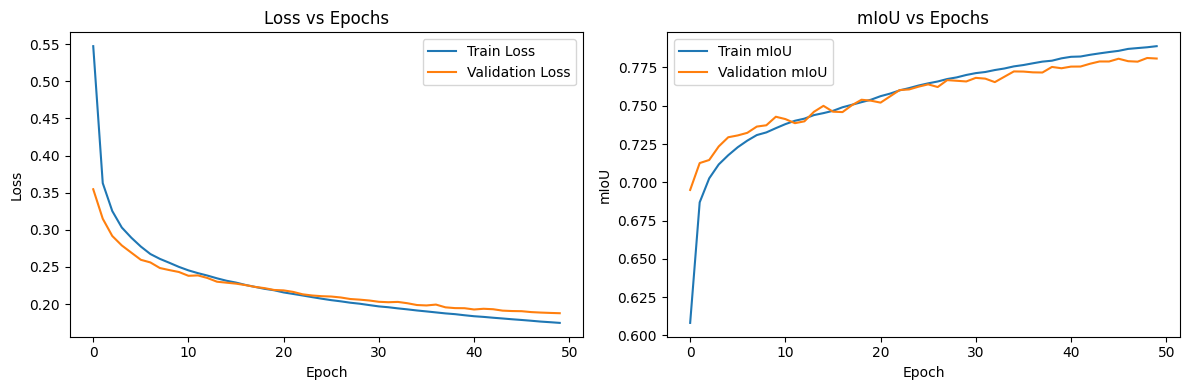

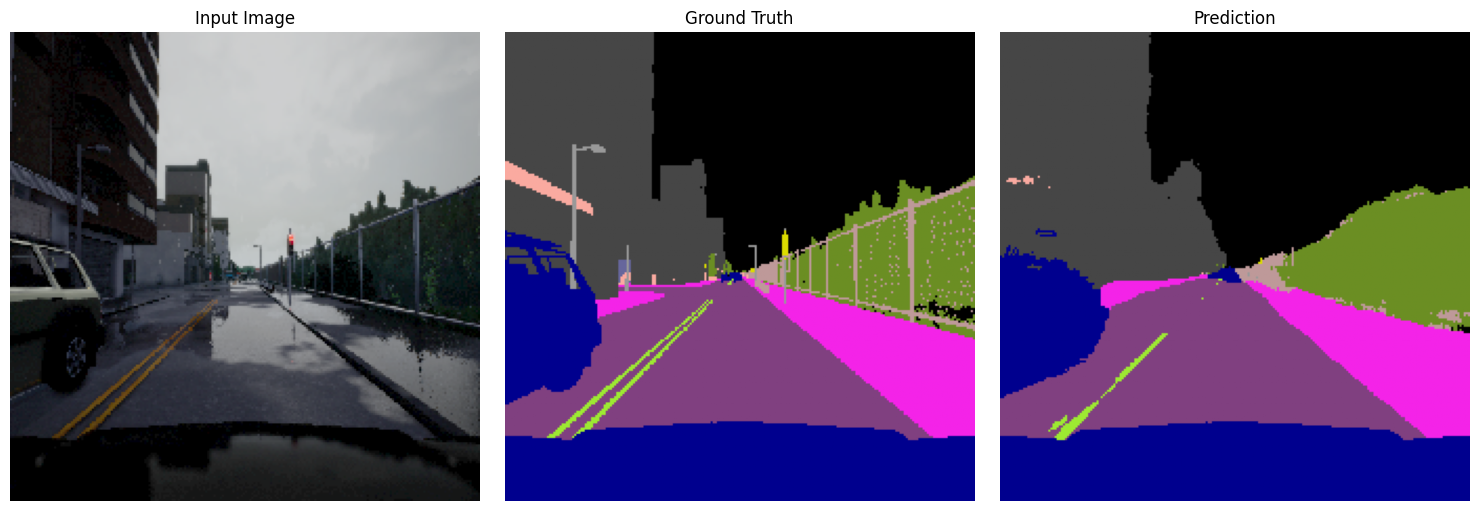

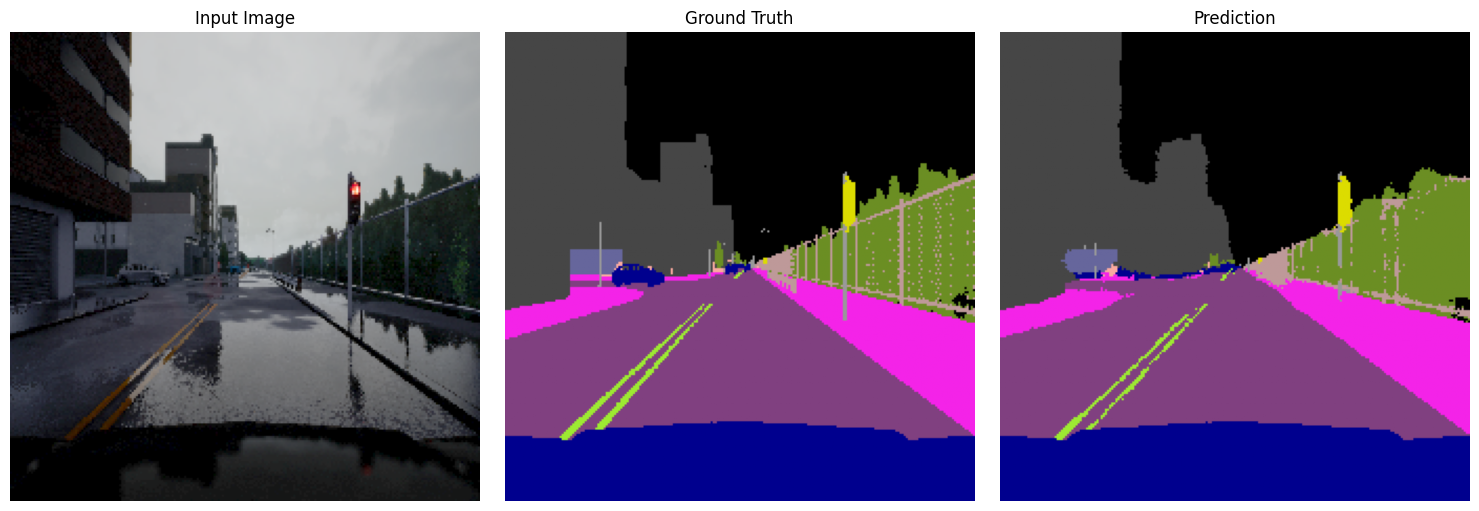

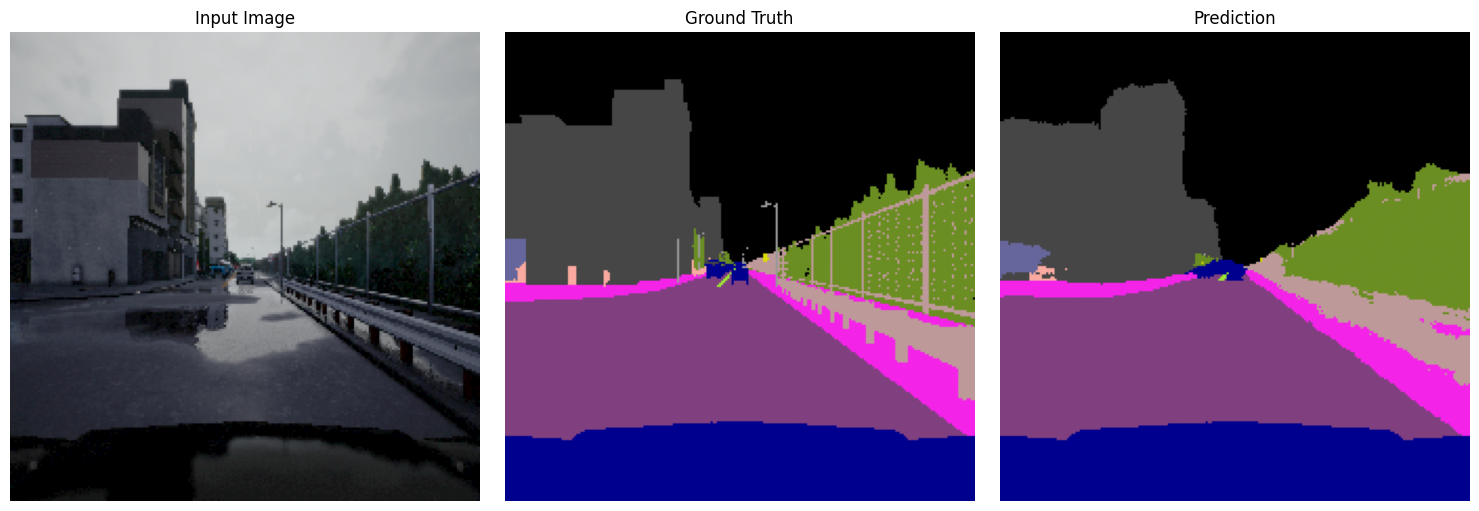

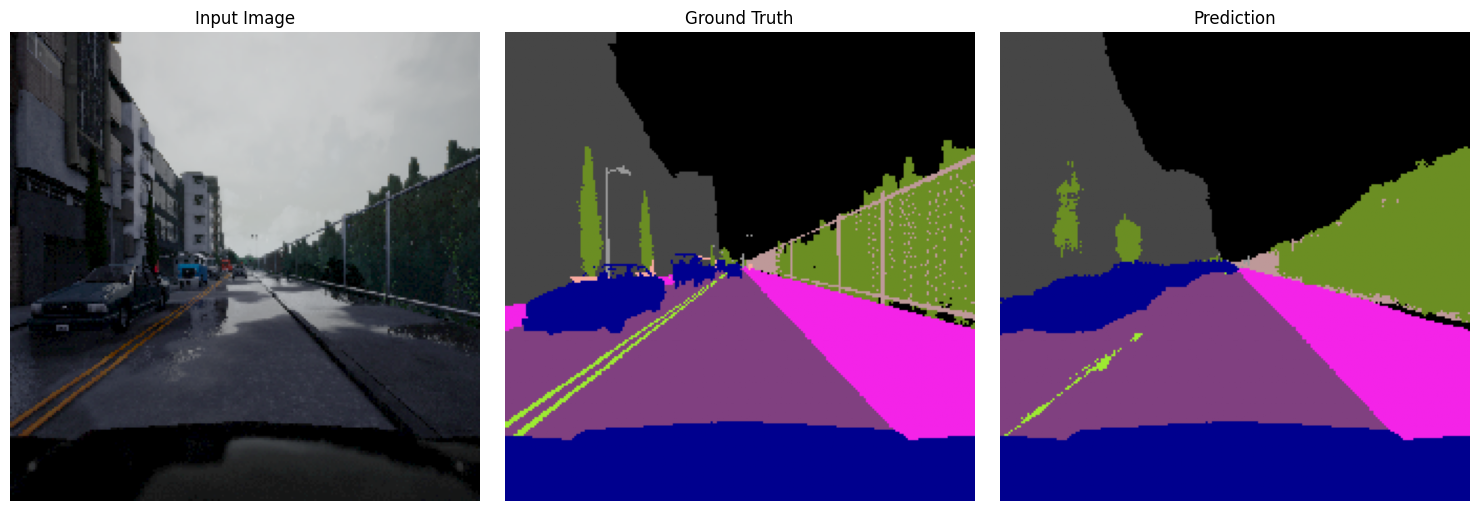

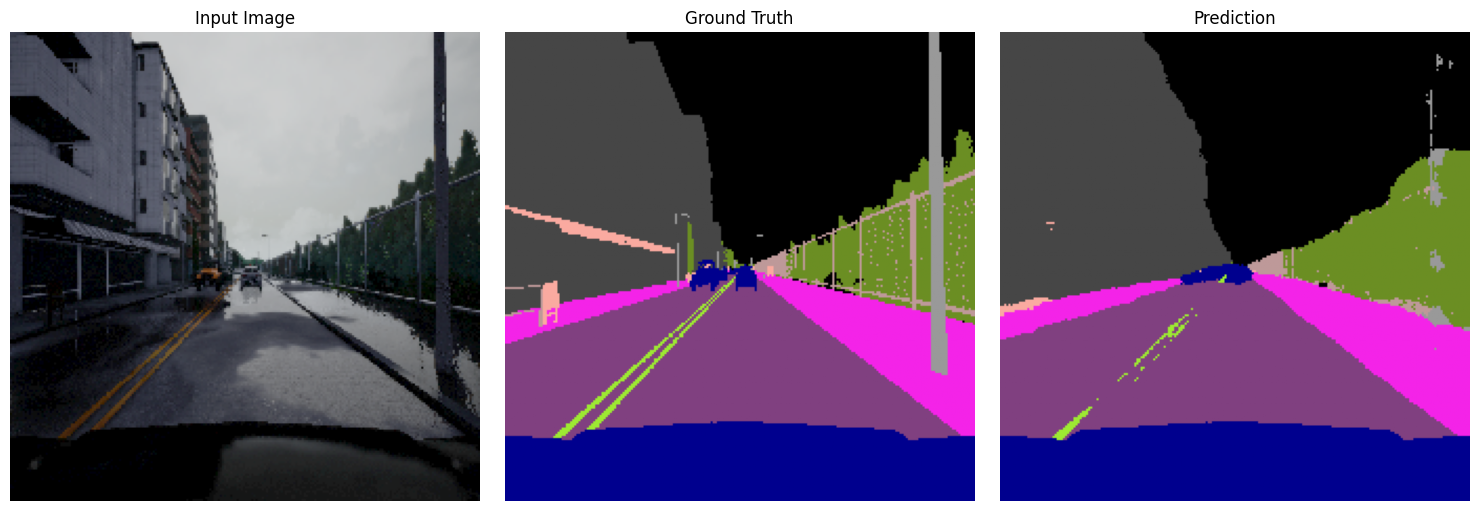


Training FCN-16s-FT with fine-tuning...


Epoch 1/50: 100%|██████████| 500/500 [00:39<00:00, 12.53it/s]


Epoch 1/50:
Train Loss: 0.5135, Train mIoU: 0.6708
Val Loss: 0.3112, Val mIoU: 0.7345


Epoch 2/50: 100%|██████████| 500/500 [00:42<00:00, 11.89it/s]


Epoch 2/50:
Train Loss: 0.2969, Train mIoU: 0.7380
Val Loss: 0.2672, Val mIoU: 0.7529


...

Epoch 48/50:
Train Loss: 0.1335, Train mIoU: 0.8210
Val Loss: 0.1643, Val mIoU: 0.8042


Epoch 49/50: 100%|██████████| 500/500 [00:41<00:00, 12.04it/s]


Epoch 49/50:
Train Loss: 0.1326, Train mIoU: 0.8217
Val Loss: 0.1640, Val mIoU: 0.8036


Epoch 50/50: 100%|██████████| 500/500 [00:41<00:00, 12.05it/s]


Epoch 50/50:
Train Loss: 0.1318, Train mIoU: 0.8222
Val Loss: 0.1630, Val mIoU: 0.8054


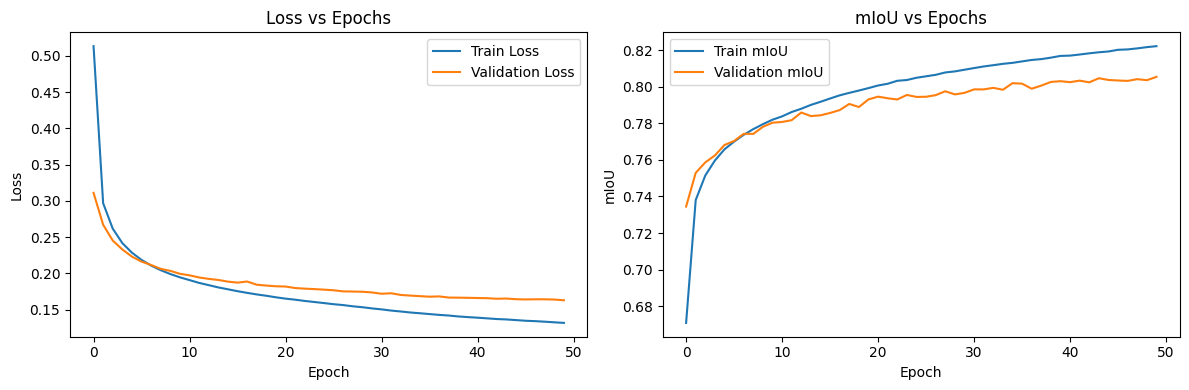

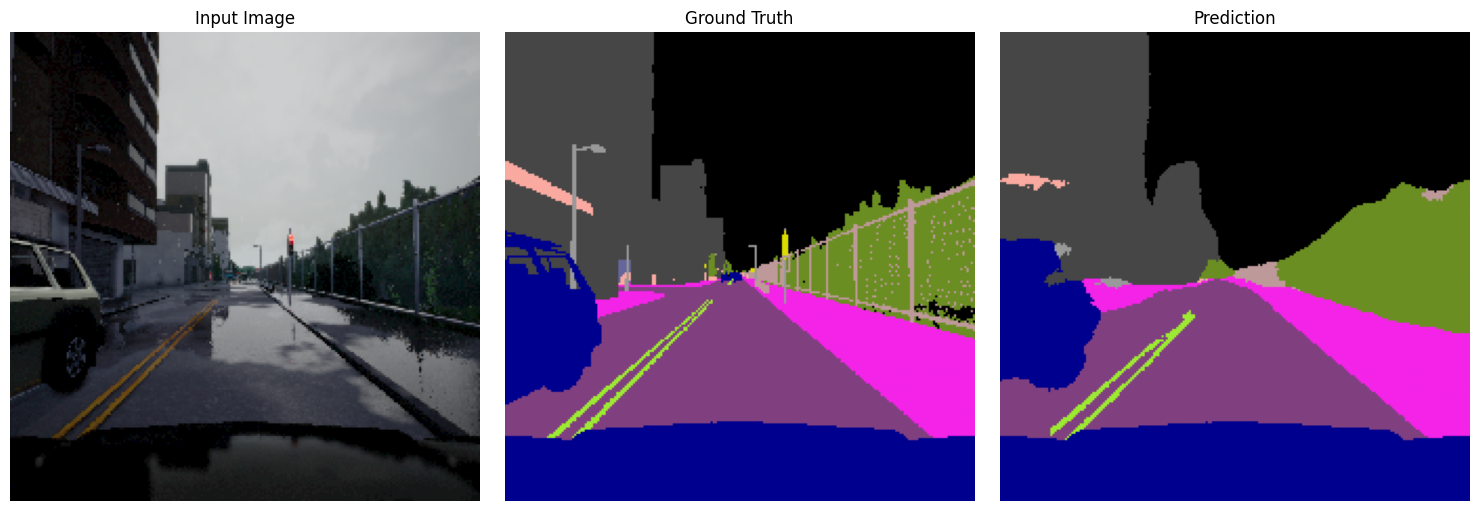

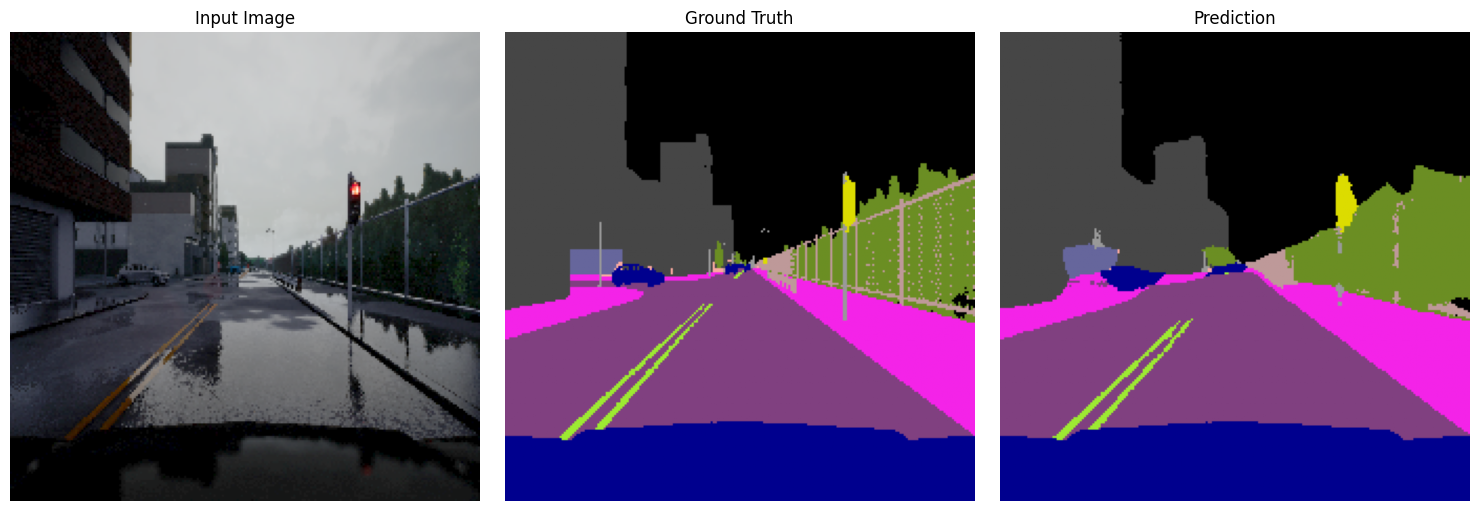

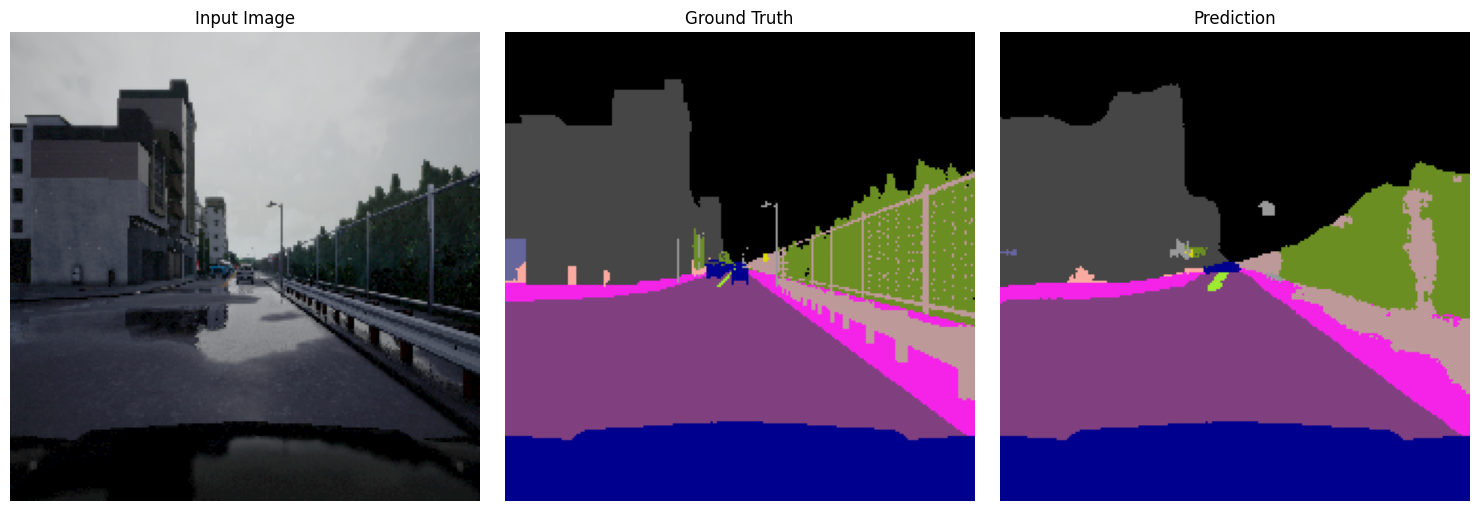

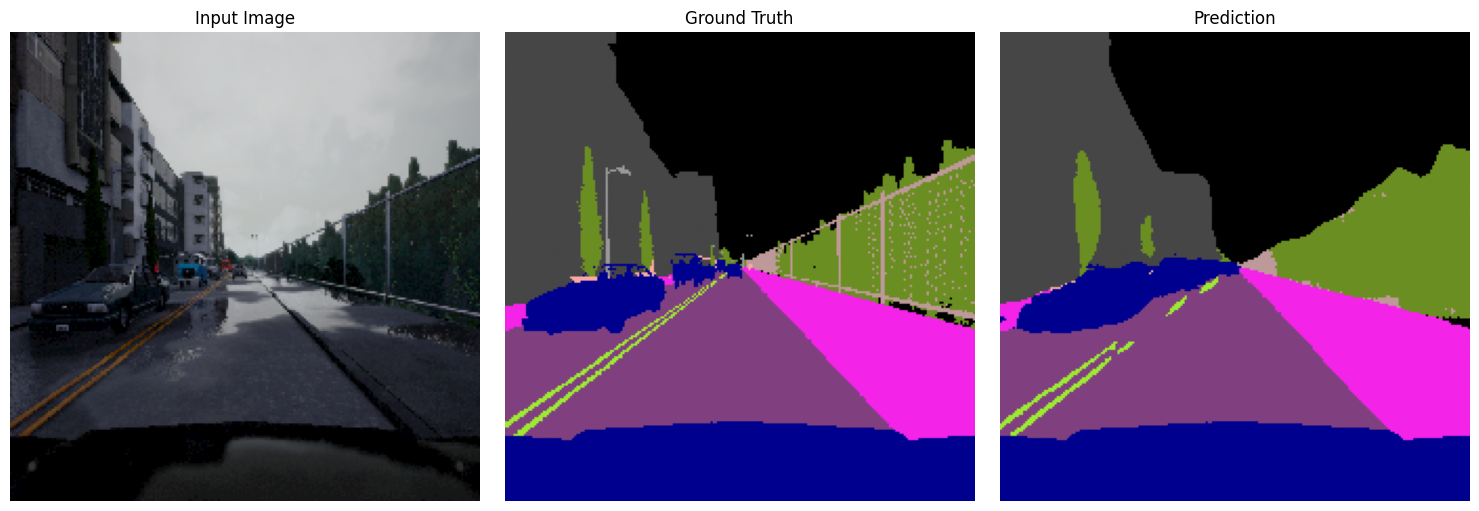

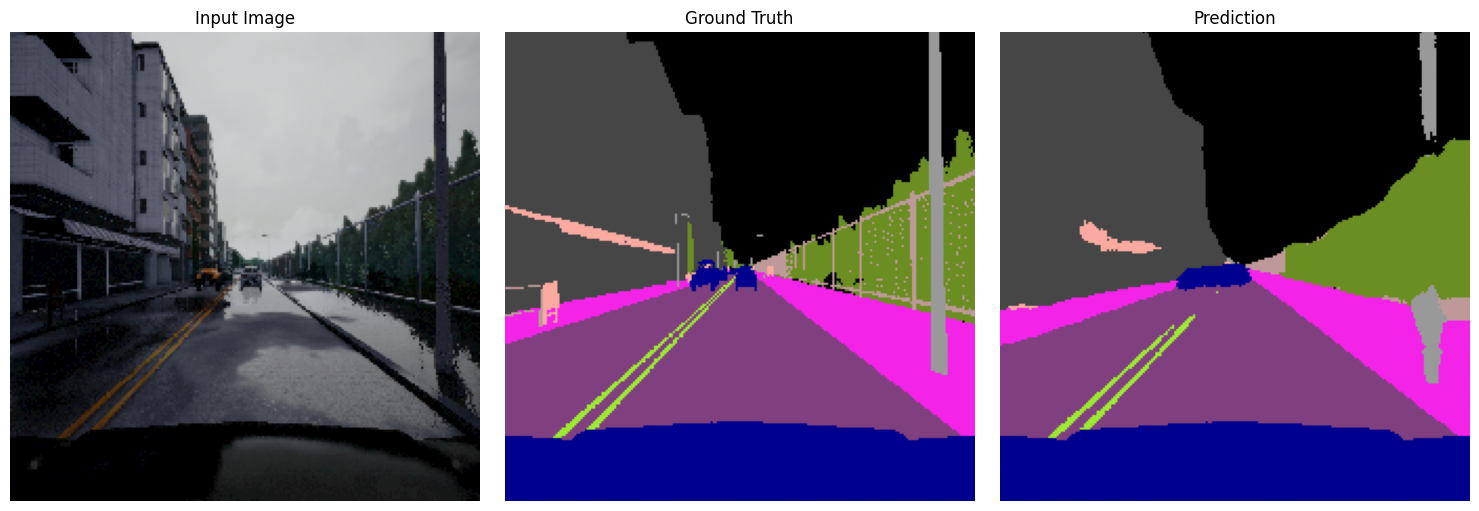


Training FCN-8s-FT with fine-tuning...


Epoch 1/50: 100%|██████████| 500/500 [00:39<00:00, 12.56it/s]


Epoch 1/50:
Train Loss: 0.5944, Train mIoU: 0.6726
Val Loss: 0.3164, Val mIoU: 0.7471


Epoch 2/50: 100%|██████████| 500/500 [00:41<00:00, 12.02it/s]


Epoch 2/50:
Train Loss: 0.2991, Train mIoU: 0.7513
Val Loss: 0.2635, Val mIoU: 0.7617


...

Epoch 48/50:
Train Loss: 0.1140, Train mIoU: 0.8395
Val Loss: 0.1326, Val mIoU: 0.8277


Epoch 49/50: 100%|██████████| 500/500 [00:41<00:00, 12.11it/s]


Epoch 49/50:
Train Loss: 0.1133, Train mIoU: 0.8401
Val Loss: 0.1323, Val mIoU: 0.8276


Epoch 50/50: 100%|██████████| 500/500 [00:41<00:00, 12.12it/s]


Epoch 50/50:
Train Loss: 0.1127, Train mIoU: 0.8405
Val Loss: 0.1328, Val mIoU: 0.8275


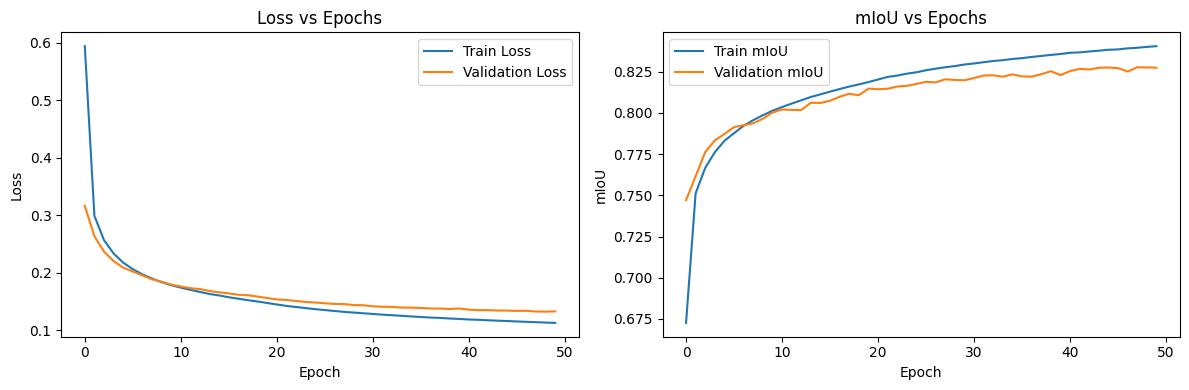

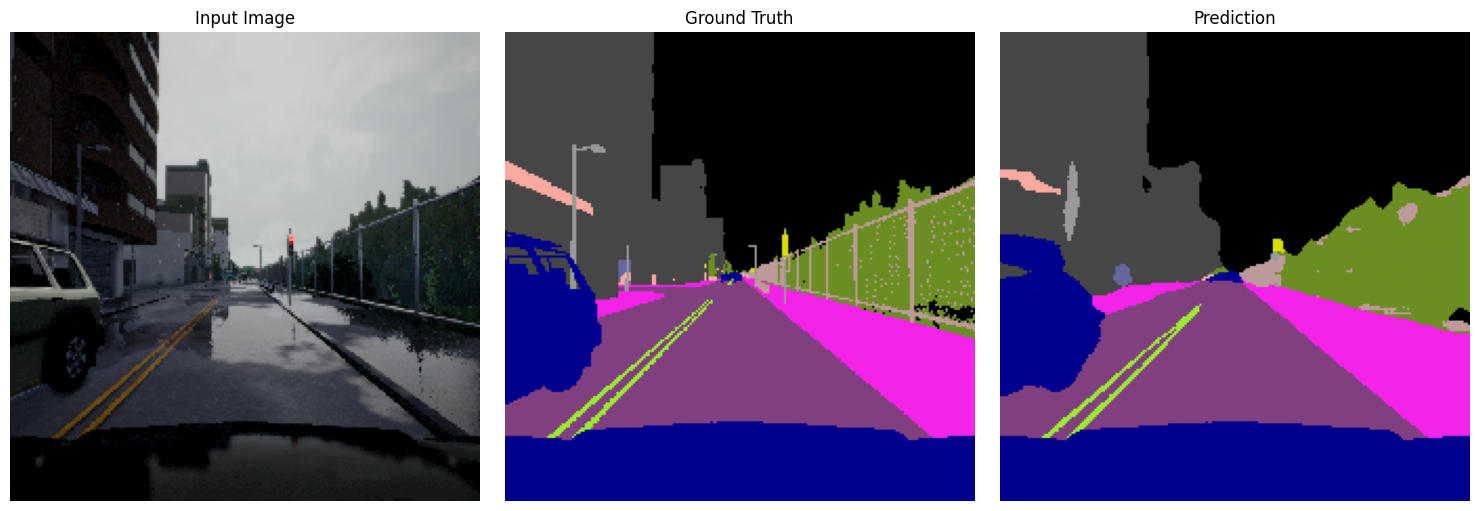

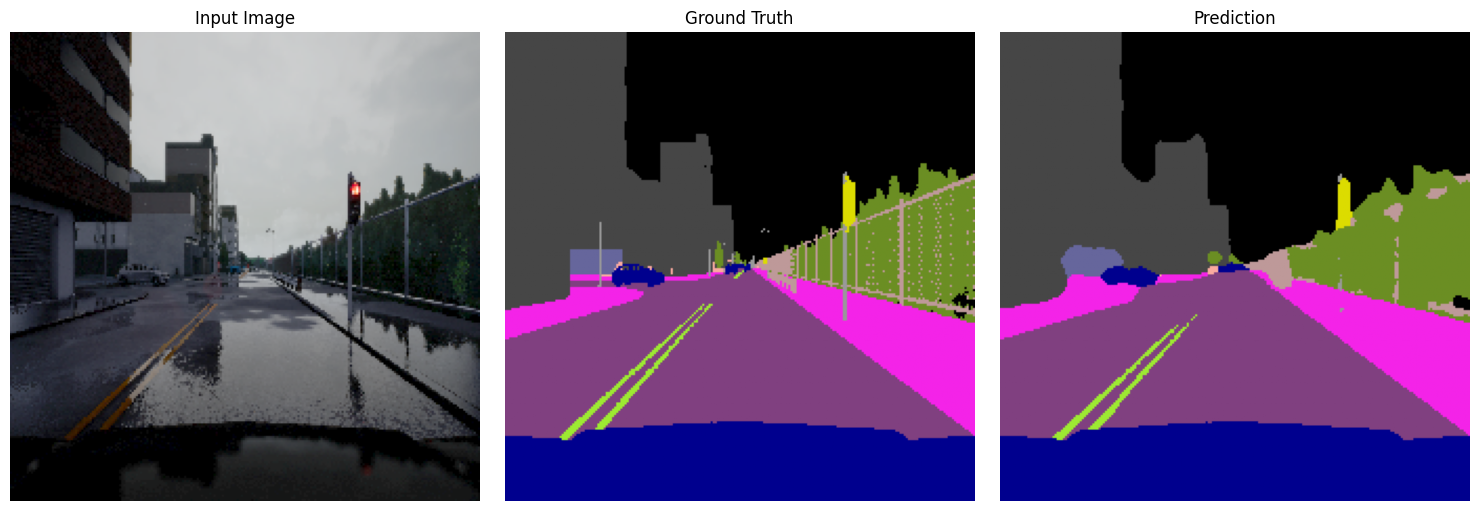

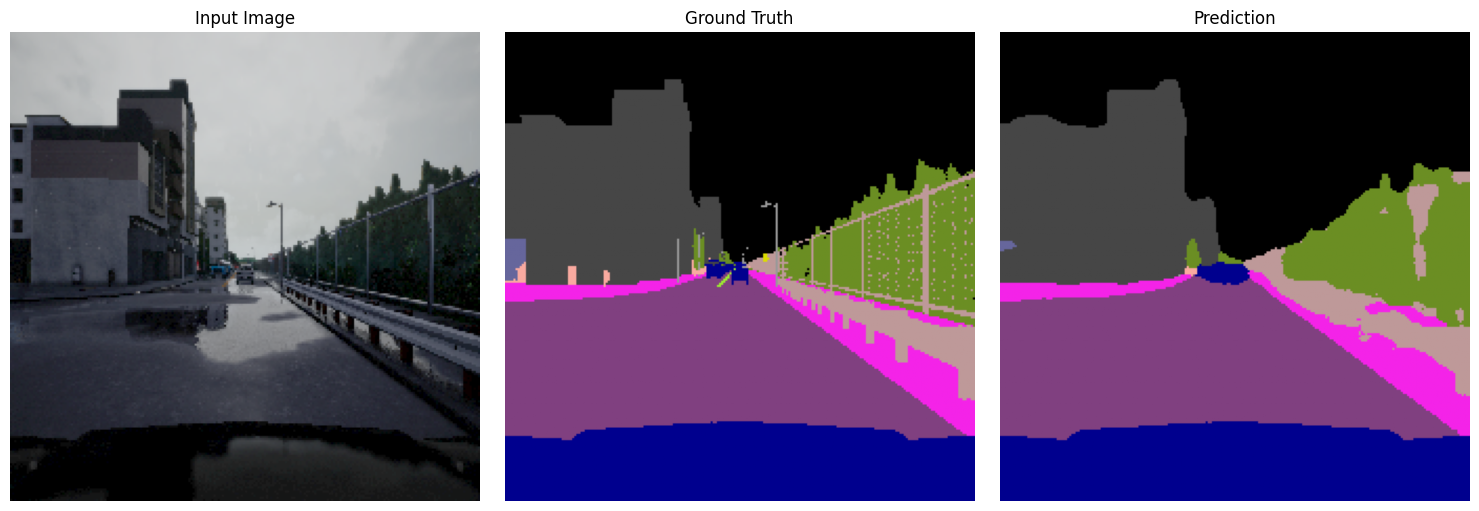

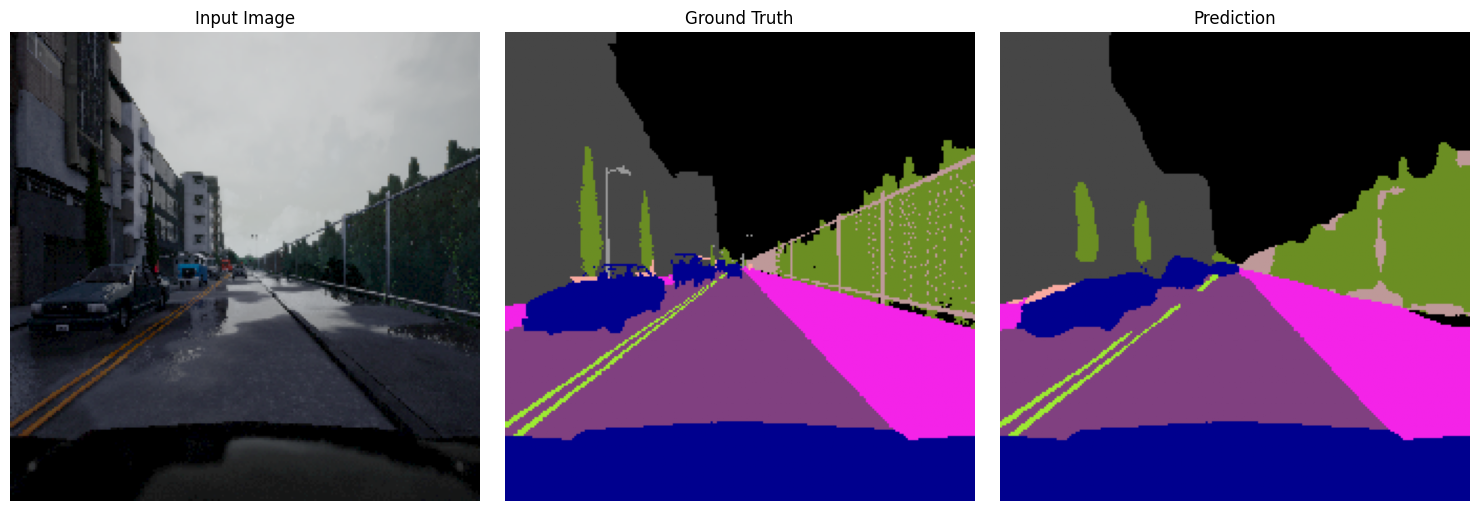

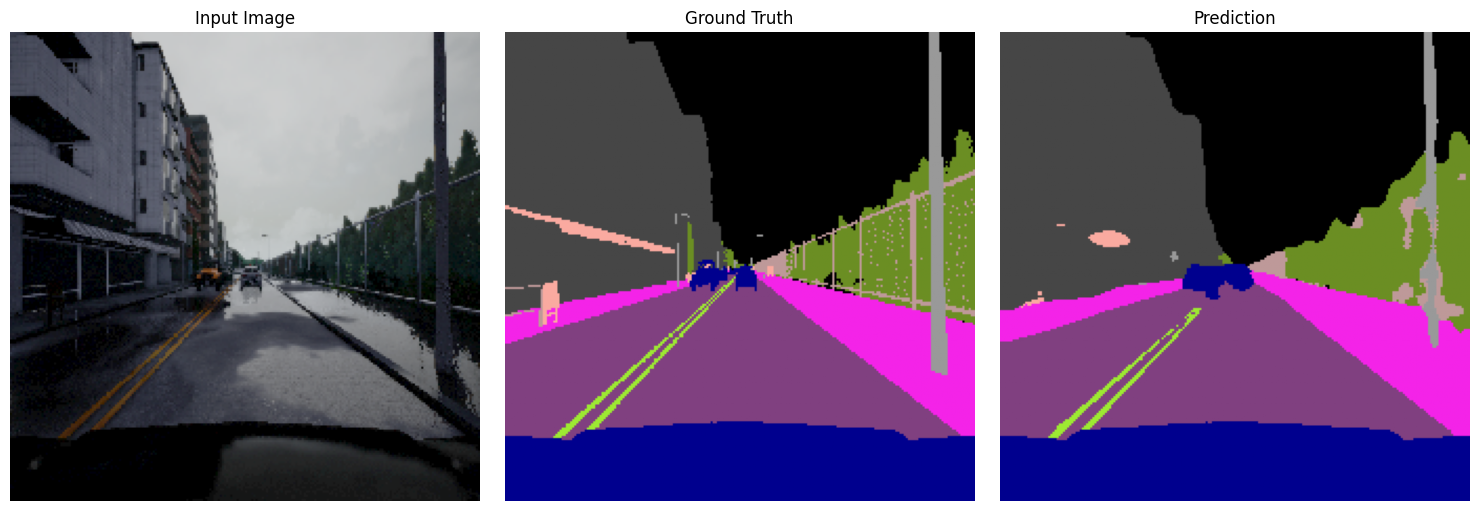

In [ ]:
import torch
# from dataset import get_data_loaders
# from models_finetuned import FCN32s_FineTuned, FCN16s_FineTuned, FCN8s_FineTuned
# from train import train_model, plot_training_history, visualize_predictions

def main():
    # Set device
    device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
    
    # Create data loaders
    data_dir = "Dataset/1/dataset_224"
    train_loader, test_loader = get_data_loaders(data_dir, batch_size=4)
    
    # Train and evaluate each FCN variant with fine-tuning
    models = {
        'FCN-32s-FT': FCN32s_FineTuned(num_classes=13),
        'FCN-16s-FT': FCN16s_FineTuned(num_classes=13),
        'FCN-8s-FT': FCN8s_FineTuned(num_classes=13)
    }
    
    for model_name, model in models.items():
        print(f"\nTraining {model_name} with fine-tuning...")
        
        # Train model with a smaller learning rate for fine-tuning
        history = train_model(
            model=model,
            train_loader=train_loader,
            test_loader=test_loader,
            num_epochs=50,
            device=device,
            learning_rate=1e-5  # Smaller learning rate for fine-tuning
        )
        
        # Plot training curves
        plot_training_history(history)
        
        # Visualize predictions
        visualize_predictions(
            model=model,
            test_loader=test_loader,
            device=device,
            num_samples=5
        )
        
        # Save model
        torch.save(model.state_dict(), f'{model_name.lower()}_model.pth')

if __name__ == '__main__':
    main()